# Exploratory Data Analysis

Dataset: **IPBlock Fraud Detection** (Amazon Fraud Dataset Benchmark)

This notebook corresponds to **Section 3.3 "Exploratory Data Analysis"** of
the paper, applied to the IPBlock fraud detection dataset.

It inspects the target distribution, temporal characteristics, IP-block
prevalence, and feature engineering produced by the fraud pipeline. The
dataset itself ships pre-cleaned and pre-split (Amazon FDB), so there is no
separate cleaning notebook for this dataset.

> **Environment**: any of the three environments works (only pandas,
> matplotlib and seaborn are required); the `.ldp` environment is recommended.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
ROOT = Path.cwd().resolve()                 # FraudDetection/notebooks
DATA_RAW = ROOT.parent / "data" / "raw"
FIG_DIR = ROOT.parent / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "EVENT_LABEL"

# Style configuration
sns.set_context("notebook", font_scale=1.2)
colors = ["#0b4e9e", "#ffc203"]   # Blue and Yellow
sns.set_palette(colors)


### Load and concatenate train + test partitions

In [2]:
# Concatenate train and test (EDA only) for a global view of the dataset
df_train = pd.read_csv(DATA_RAW / "ipblock_train.csv")
df_test_features = pd.read_csv(DATA_RAW / "ipblock_test_features.csv")
df_test_labels = pd.read_csv(DATA_RAW / "ipblock_test_labels.csv")

# Align test labels with test features via EVENT_ID
df_test = df_test_features.merge(
    df_test_labels[["EVENT_ID", TARGET]], on="EVENT_ID", how="left"
)

raw_data = pd.concat([df_train, df_test], ignore_index=True)
print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)
print("Total shape:", raw_data.shape)


Train shape: (172000, 8)
Test shape : (43000, 7)
Total shape: (215000, 8)


### Target distribution (Figure 2b of the paper)

C:\Users\danie\AppData\Local\Temp\ipykernel_11200\3178349489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=TARGET, data=raw_data, palette=colors, ax=ax)
C:\Users\danie\AppData\Local\Temp\ipykernel_11200\3178349489.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No fraud", "Fraud"])


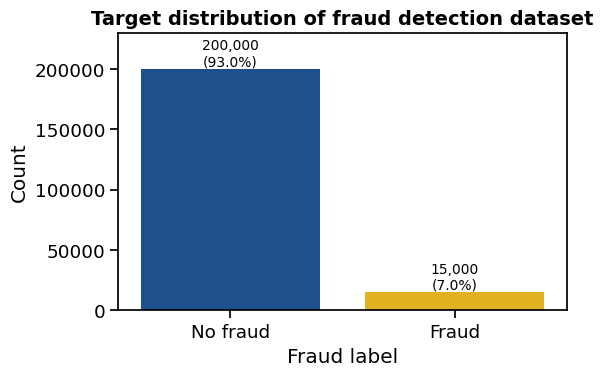

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=TARGET, data=raw_data, palette=colors, ax=ax)
ax.set_title("Target distribution of fraud detection dataset", fontsize=14, weight="bold")
ax.set_xlabel("Fraud label")
ax.set_ylabel("Count")
ax.set_xticklabels(["No fraud", "Fraud"])

# Annotate counts and percentages
totals = raw_data[TARGET].value_counts().sort_index()
for i, count in enumerate(totals):
    pct = 100.0 * count / totals.sum()
    ax.text(i, count, f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, totals.max() * 1.15)
plt.tight_layout()
plt.show()


### Event timing patterns

C:\Users\danie\AppData\Local\Temp\ipykernel_11200\164204602.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_rate.index, y=dow_rate.values, ax=axs[1], palette=colors)
C:\Users\danie\AppData\Local\Temp\ipykernel_11200\164204602.py:22: UserWarning: 
The palette list has fewer values (2) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=dow_rate.index, y=dow_rate.values, ax=axs[1], palette=colors)
C:\Users\danie\AppData\Local\Temp\ipykernel_11200\164204602.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])


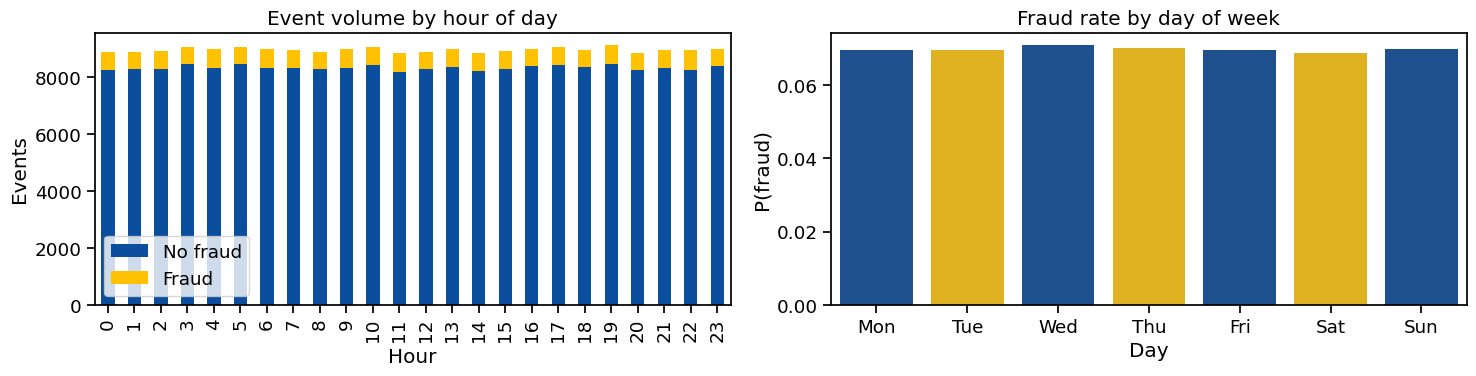

In [4]:
# Decompose EVENT_TIMESTAMP into temporal features
ts = pd.to_datetime(raw_data["EVENT_TIMESTAMP"], errors="coerce")
raw_data["event_hour"] = ts.dt.hour
raw_data["event_dow"]  = ts.dt.dayofweek

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

# Hour of day: stacked counts
hour_counts = (
    raw_data.groupby(["event_hour", TARGET]).size()
            .unstack(fill_value=0)
            .reindex(range(24), fill_value=0)
)
hour_counts.plot(kind="bar", stacked=True, ax=axs[0], color=colors)
axs[0].set_title("Event volume by hour of day")
axs[0].set_xlabel("Hour")
axs[0].set_ylabel("Events")
axs[0].legend(["No fraud", "Fraud"])

# Day of week: fraud rate
dow_rate = raw_data.groupby("event_dow")[TARGET].mean()
sns.barplot(x=dow_rate.index, y=dow_rate.values, ax=axs[1], palette=colors)
axs[1].set_title("Fraud rate by day of week")
axs[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axs[1].set_xlabel("Day")
axs[1].set_ylabel("P(fraud)")

plt.tight_layout()
plt.show()


### IP-block analysis

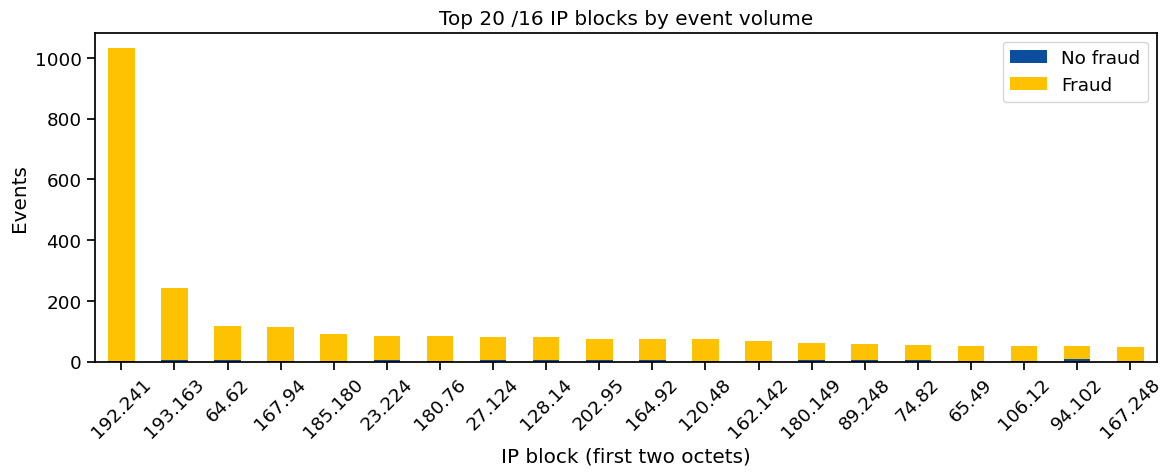

In [5]:
# Top IP blocks (first two octets) by event volume, segmented by target
ip_oct1 = raw_data["ip"].astype(str).str.split(".").str[0]
ip_oct2 = raw_data["ip"].astype(str).str.split(".").str[1]
raw_data["ip_block"] = ip_oct1 + "." + ip_oct2

top_blocks = raw_data["ip_block"].value_counts().head(20).index
subset = raw_data[raw_data["ip_block"].isin(top_blocks)]

fig, ax = plt.subplots(figsize=(12, 5))
counts = (
    subset.groupby(["ip_block", TARGET]).size()
          .unstack(fill_value=0)
          .reindex(top_blocks)
)
counts.plot(kind="bar", stacked=True, ax=ax, color=colors)
ax.set_title("Top 20 /16 IP blocks by event volume")
ax.set_xlabel("IP block (first two octets)")
ax.set_ylabel("Events")
ax.legend(["No fraud", "Fraud"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
